<a href="https://colab.research.google.com/github/Priyanshu5266/bpta/blob/main/Priyanshu_BPTA_P3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import time
import pandas as pd

In [ ]:
n=20

In [ ]:
m_values=[20,40,60,80,100,120,140,160,180,190]

In [ ]:
all_edges=[]

for i in range(n):
  for j in range(i+1,n):
    all_edges.append((i,j))

In [ ]:
random.seed=10

datasets={}
for m in m_values:
  edges= random.sample(all_edges,m)
  datasets[m]=edges

In [ ]:
with open("vertex_greedy_datasets.pkl","wb") as file:
  pickle.dump(datasets, file)
print("save")

save


In [ ]:
def is_vertex_cover(cover,edges):
  for edge in edges:
    u=edge[0]
    v=edge[1]

    if u not in cover and v not in cover:
      return False

  return True

In [ ]:
def brute_force_vertex_cover(n,edges):
  best_cover= None
  for mask in range(2**n):

    cover=[]

    for i in range(n):

      if mask & (1<<i):
        cover.append(i)

    if is_vertex_cover(cover,edges):
      if best_cover is None or len(cover) < len(best_cover):
        best_cover= cover

  return best_cover

In [ ]:
def greedy_vertex_cover(edges):

  matched=set()
  matching=[]

  for edge in edges:
    u=edge[0]
    v=edge[1]

    if u not in matched and v not in matched:
      matching.append((u,v))

      matched.add(u)
      matched.add(v)

  vertex_cover=[]

  for edge in matching:
    u = edge[0]
    v = edge[1]


    vertex_cover.append(u)
    vertex_cover.append(v)

  return matching, vertex_cover

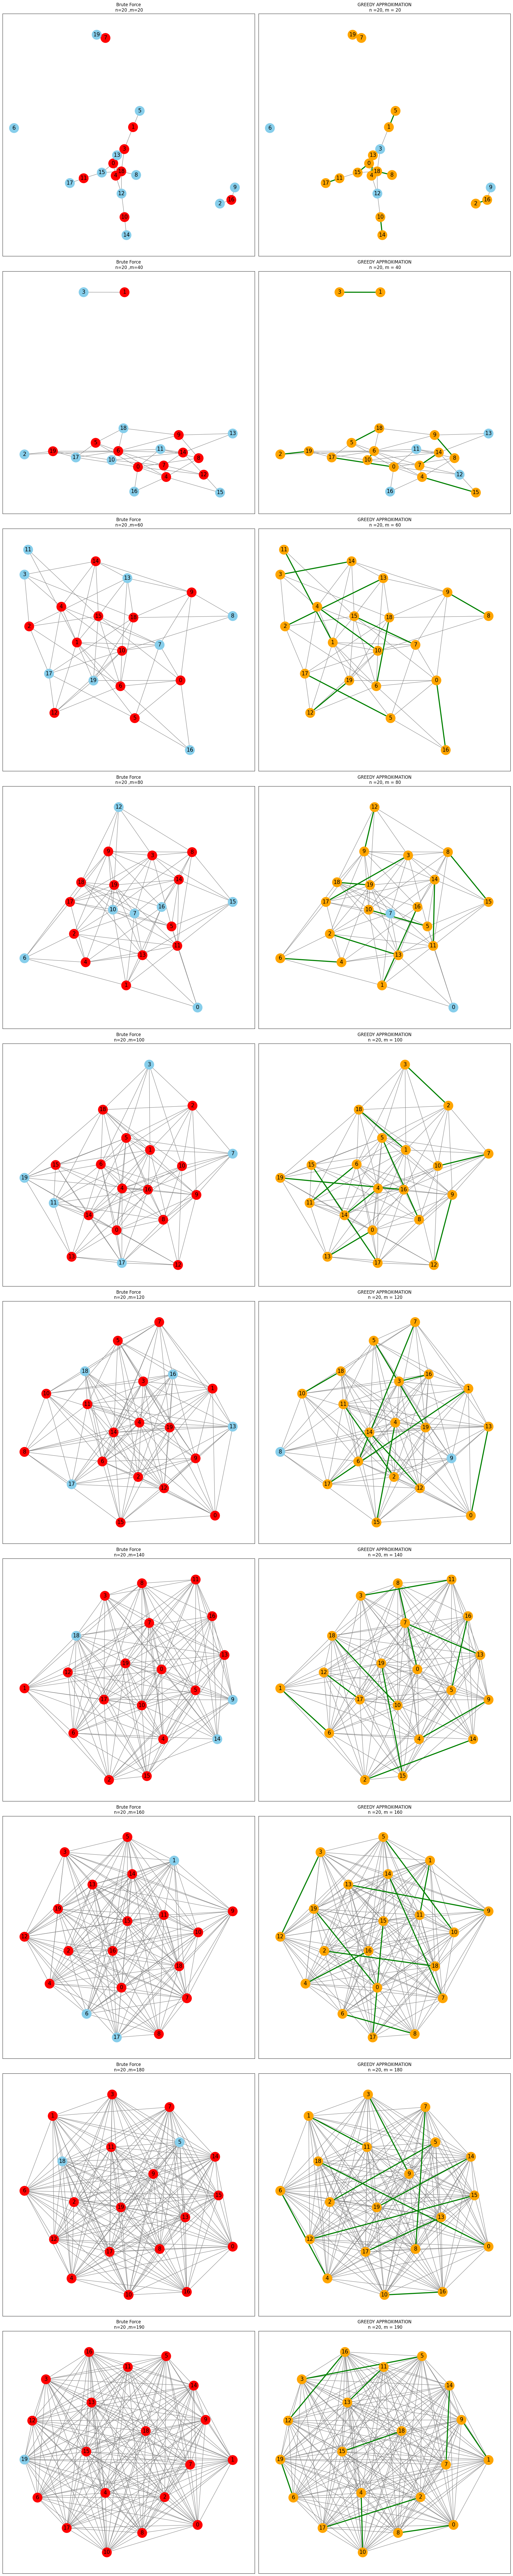

In [ ]:
fig,axes = plt.subplots(10,2,figsize=(20,100))

for index,m in enumerate(m_values):

  edges=datasets[m]

  G=nx.Graph()
  G.add_nodes_from(range(n))
  G.add_edges_from(edges)

  brute_force= brute_force_vertex_cover(n,edges)
  matching, greedy_cover  = greedy_vertex_cover(edges)

  pos=nx.spring_layout(G, seed=10)

  ax = axes.flat[2 * index]

  node_colors = []
  for node in G.nodes():
    if node in brute_force:
      node_colors.append("red")
    else:
      node_colors.append("skyblue")

  nx.draw_networkx_edges(G, pos, ax=ax, edge_color="gray", width=1)
  nx.draw_networkx_nodes(
      G, pos, ax=ax,
      node_color=node_colors,
      node_size=700
  )
  nx.draw_networkx_labels(G, pos, ax=ax, font_size=15)

  ax.set_title("Brute Force\n n=20 ,m="+str(m))



  ax = axes.flat[2 * index + 1]

  node_colors = []
  for node in G.nodes():
    if node in greedy_cover:
      node_colors.append("orange")
    else:
      node_colors.append("skyblue")

  nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color="gray",
        width=1
    )

  nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=matching,
        edge_color="green",
        width=3
    )

  nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_colors,
        node_size=700
    )

  nx.draw_networkx_labels(
        G, pos, ax=ax,
        font_size=15
    )

  ax.set_title(
      "GREEDY APPROXIMATION\n n =20, m = " + str(m))




plt.tight_layout()
plt.savefig(
    "practical3_brute_greedy_graph.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



In [ ]:
results =[]

for m in m_values:

  edges= datasets[m]
  #brute force
  start_time= time.perf_counter()
  brute_force= brute_force_vertex_cover(n,edges)
  end_time= time.perf_counter()

  brute_running_time= end_time - start_time
  brute_cover_size= len(brute_force)
  #greedy
  start_time= time.perf_counter()
  matching, greedy_cover  = greedy_vertex_cover(edges)
  end_time= time.perf_counter()

  greedy_running_time= end_time - start_time
  greedy_cover_size= len(greedy_cover)

  #aproxmiation factor
  approx_factor= greedy_cover_size/brute_cover_size

  results.append((n,m,brute_cover_size,brute_running_time,greedy_cover_size,greedy_running_time,approx_factor))


In [ ]:
df=pd.DataFrame(results,columns=["n","m","brute_cover_size","brute_running_time","greedy_cover_size","greedy_running_time","approx_factor"])
df

,n,m,brute_cover_size,brute_running_time,greedy_cover_size,greedy_running_time,approx_factor
0,20,20,9,3.027613,16,0.000025,1.777778
1,20,40,11,3.183403,16,0.000025,1.454545
2,20,60,12,3.882937,20,0.000049,1.666667
3,20,80,13,4.025443,18,0.000026,1.384615
4,20,100,15,3.190699,20,0.000052,1.333333
5,20,120,16,3.188595,18,0.000042,1.125000
6,20,140,17,4.673155,20,0.000042,1.176471
7,20,160,17,3.182510,20,0.000036,1.176471
8,20,180,18,3.174005,20,0.000038,1.111111
9,20,190,19,3.199736,20,0.000037,1.052632
